# Week 5 — Demand Forecasting
## Supply Chain Intelligence Project

**Input:** `cleaned_supply_chain.csv` (from Week 1)  
**Output:** `forecast_model.pkl`, `daily_demand.csv`, `monthly_demand.csv`, `forecast_results.csv`

### Objectives
1. Build daily & monthly demand time series
2. Analyse seasonality and trends
3. Train Prophet forecasting model
4. Forecast next 6 months of demand
5. Forecast by product category
6. Evaluate model accuracy
7. Business insights from forecast

---
## 0. Install Prophet

In [1]:
# Run this cell first if Prophet is not installed
!pip install prophet

---
## 1. Imports & Load Data

In [2]:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import matplotlib.pyplot as plt
import warnings
import os
import pickle

from prophet import Prophet
from prophet.diagnostics import cross_validation, performance_metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error

warnings.filterwarnings('ignore')
os.makedirs('../outputs', exist_ok=True)
os.makedirs('../models', exist_ok=True)
os.makedirs('../data/processed', exist_ok=True)

# ── Load clean data ────────────────────────────────────────────
df = pd.read_csv('../data/processed/cleaned_supply_chain.csv',
                 parse_dates=['Order Date', 'Ship Date'])

print(f'Dataset shape : {df.shape}')
print(f'Date range    : {df["Order Date"].min().date()} → {df["Order Date"].max().date()}')
print('Data loaded ✓')

Dataset shape : (180519, 49)
Date range    : 2015-01-01 → 2018-01-31
Data loaded ✓


---
## 2. Build Time Series — Daily & Monthly Demand

In [3]:
# ── Daily demand ───────────────────────────────────────────────
daily = df.groupby(df['Order Date'].dt.date).agg(
    Orders  = ('Revenue', 'count'),
    Revenue = ('Revenue', 'sum'),
    Qty     = ('Order Item Quantity', 'sum')
).reset_index()
daily['Order Date'] = pd.to_datetime(daily['Order Date'])
daily = daily.sort_values('Order Date').reset_index(drop=True)

# ── Monthly demand ─────────────────────────────────────────────
monthly = df.groupby('Order_YearMonth').agg(
    Orders  = ('Revenue', 'count'),
    Revenue = ('Revenue', 'sum'),
    Qty     = ('Order Item Quantity', 'sum')
).reset_index()
monthly['Order Date'] = pd.to_datetime(monthly['Order_YearMonth'])
monthly = monthly.sort_values('Order Date').reset_index(drop=True)

# Save
daily.to_csv('../data/processed/daily_demand.csv', index=False)
monthly.to_csv('../data/processed/monthly_demand.csv', index=False)

print(f'Daily time series  : {len(daily)} days')
print(f'Monthly time series: {len(monthly)} months')
print(f'Avg daily orders   : {daily["Orders"].mean():.0f}')
print(f'Avg monthly revenue: ${monthly["Revenue"].mean():,.0f}')
print('Time series built ✓')

Daily time series  : 1127 days
Monthly time series: 37 months
Avg daily orders   : 160
Avg monthly revenue: $994,182
Time series built ✓


---
## 3. Exploratory Time Series Analysis

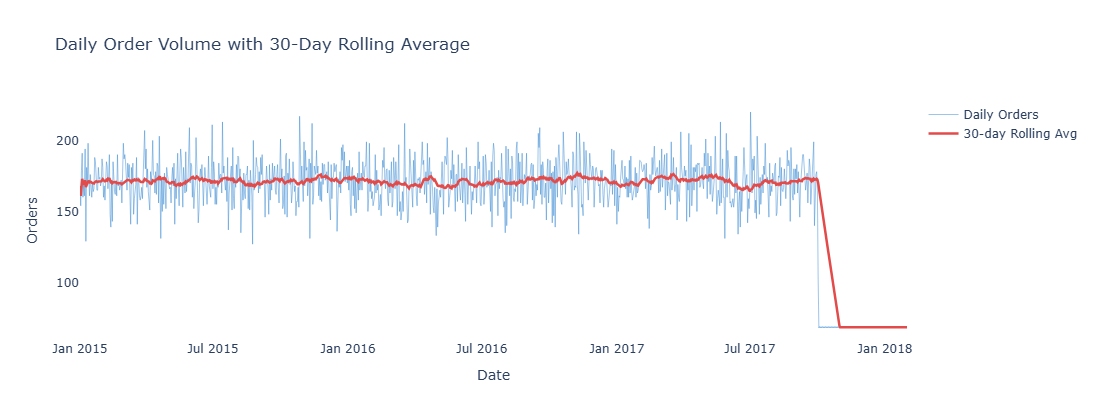

Chart 1 saved ✓


In [4]:
# ── Chart 1: Daily order volume with 30-day rolling average ───
daily['Rolling30'] = daily['Orders'].rolling(window=30, min_periods=1).mean()

fig = go.Figure()
fig.add_trace(go.Scatter(
    x=daily['Order Date'], y=daily['Orders'],
    mode='lines', name='Daily Orders',
    line=dict(color='#3B8BD4', width=1), opacity=0.5
))
fig.add_trace(go.Scatter(
    x=daily['Order Date'], y=daily['Rolling30'],
    mode='lines', name='30-day Rolling Avg',
    line=dict(color='#E24B4A', width=2.5)
))
fig.update_layout(
    title='Daily Order Volume with 30-Day Rolling Average',
    xaxis_title='Date', yaxis_title='Orders',
    plot_bgcolor='white', height=420
)
fig.write_html('../outputs/forecast_daily_orders.html')
fig.show()
print('Chart 1 saved ✓')

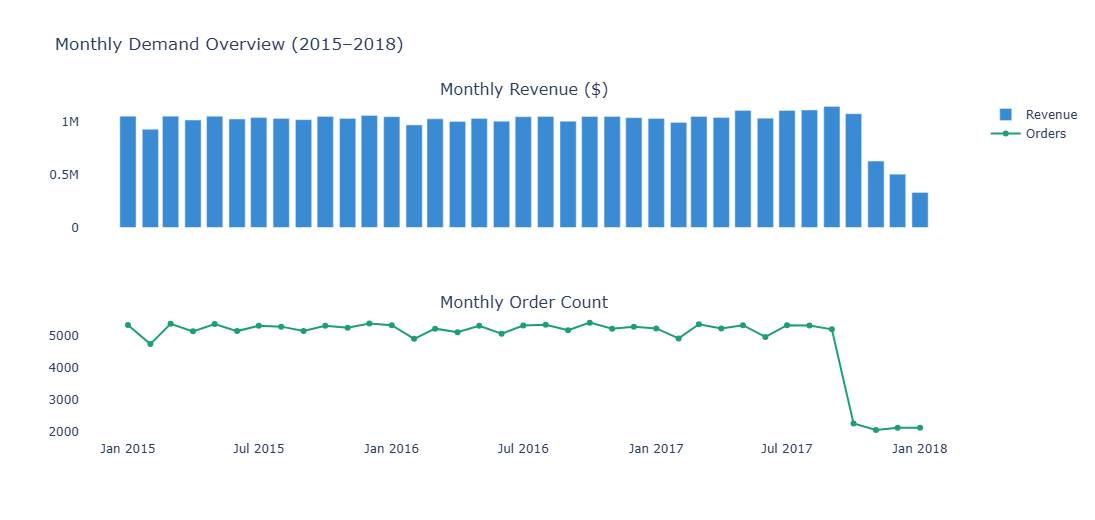

Chart 2 saved ✓


In [5]:
# ── Chart 2: Monthly revenue trend ────────────────────────────
fig = make_subplots(rows=2, cols=1,
    subplot_titles=('Monthly Revenue ($)', 'Monthly Order Count'),
    shared_xaxes=True)

fig.add_trace(go.Bar(
    x=monthly['Order Date'], y=monthly['Revenue'],
    name='Revenue', marker_color='#3B8BD4'
), row=1, col=1)

fig.add_trace(go.Scatter(
    x=monthly['Order Date'], y=monthly['Orders'],
    mode='lines+markers', name='Orders',
    line=dict(color='#1D9E75', width=2)
), row=2, col=1)

fig.update_layout(
    title='Monthly Demand Overview (2015–2018)',
    plot_bgcolor='white', height=520
)
fig.write_html('../outputs/forecast_monthly_overview.html')
fig.show()
print('Chart 2 saved ✓')

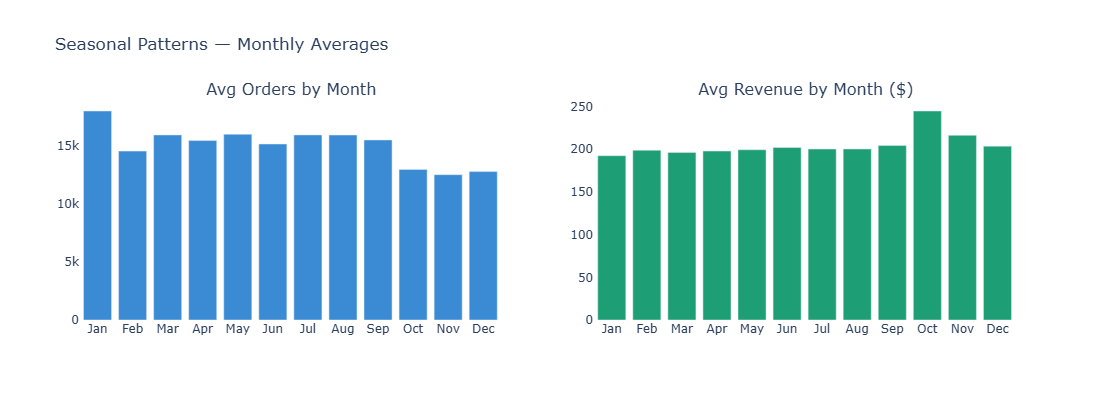

Chart 3 saved ✓


In [6]:
# ── Chart 3: Seasonality analysis ─────────────────────────────
df['Order_Month_Name'] = df['Order Date'].dt.strftime('%b')
month_order = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']

monthly_avg = df.groupby(df['Order Date'].dt.month).agg(
    Avg_Orders  = ('Revenue', 'count'),
    Avg_Revenue = ('Revenue', 'mean')
).reset_index()
monthly_avg.columns = ['Month_Num', 'Avg_Orders', 'Avg_Revenue']
monthly_avg['Month'] = [month_order[i-1] for i in monthly_avg['Month_Num']]

fig = make_subplots(rows=1, cols=2,
    subplot_titles=('Avg Orders by Month', 'Avg Revenue by Month ($)'))

fig.add_trace(go.Bar(
    x=monthly_avg['Month'], y=monthly_avg['Avg_Orders'],
    marker_color='#3B8BD4', name='Avg Orders'
), row=1, col=1)

fig.add_trace(go.Bar(
    x=monthly_avg['Month'], y=monthly_avg['Avg_Revenue'],
    marker_color='#1D9E75', name='Avg Revenue'
), row=1, col=2)

fig.update_layout(
    title='Seasonal Patterns — Monthly Averages',
    plot_bgcolor='white', height=400, showlegend=False
)
fig.write_html('../outputs/forecast_seasonality.html')
fig.show()
print('Chart 3 saved ✓')

---
## 4. Prophet Forecasting — Overall Demand

In [7]:
# ── Prepare Prophet format ─────────────────────────────────────
prophet_df = daily[['Order Date', 'Orders']].copy()
prophet_df.columns = ['ds', 'y']

# ── FIX: Remove last 60 days — likely incomplete data ─────────
cutoff = prophet_df['ds'].max() - pd.Timedelta(days=60)
prophet_df = prophet_df[prophet_df['ds'] <= cutoff].reset_index(drop=True)

# Remove outliers (orders > 3 std devs from mean)
mean_y = prophet_df['y'].mean()
std_y  = prophet_df['y'].std()
prophet_df = prophet_df[
    (prophet_df['y'] >= mean_y - 3 * std_y) &
    (prophet_df['y'] <= mean_y + 3 * std_y)
].reset_index(drop=True)

print(f'Prophet dataset: {len(prophet_df)} days')
print(f'Date range     : {prophet_df["ds"].min().date()} → {prophet_df["ds"].max().date()}')
prophet_df.head()

Prophet dataset: 1006 days
Date range     : 2015-01-01 → 2017-10-02


,ds,y
0,2015-01-01,168
1,2015-01-02,154
2,2015-01-03,179
3,2015-01-04,191
4,2015-01-05,160


In [8]:
# ── Train / Test split ─────────────────────────────────────────
# Use last 90 days as test set
cutoff_date = prophet_df['ds'].max() - pd.Timedelta(days=90)
train_df    = prophet_df[prophet_df['ds'] <= cutoff_date]
test_df     = prophet_df[prophet_df['ds'] >  cutoff_date]

print(f'Training set : {len(train_df)} days (up to {cutoff_date.date()})')
print(f'Test set     : {len(test_df)} days')

Training set : 916 days (up to 2017-07-04)
Test set     : 90 days


In [9]:
# ── Train Prophet model ────────────────────────────────────────
print('Training Prophet model...')

model = Prophet(
    yearly_seasonality  = True,
    weekly_seasonality  = True,
    daily_seasonality   = False,
    seasonality_mode    = 'multiplicative',  # better for growing trends
    changepoint_prior_scale = 0.05           # controls trend flexibility
)

model.fit(train_df)
print('Prophet model trained ✓')

Training Prophet model...


12:06:40 - cmdstanpy - INFO - Chain [1] start processing
12:06:40 - cmdstanpy - INFO - Chain [1] done processing


Prophet model trained ✓


In [10]:
# ── Forecast next 6 months (180 days) beyond dataset ──────────
future = model.make_future_dataframe(periods=180, freq='D')
forecast = model.predict(future)

print(f'Forecast generated: {len(forecast)} days')
print(f'Forecast end date : {forecast["ds"].max().date()}')
forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(10)

Forecast generated: 1096 days
Forecast end date : 2017-12-31


,ds,yhat,yhat_lower,yhat_upper
1086,2017-12-22,172.323036,154.880738,191.830871
1087,2017-12-23,171.899833,154.113505,190.011934
1088,2017-12-24,172.241534,154.571039,190.181323
1089,2017-12-25,171.624786,154.124807,190.369252
1090,2017-12-26,169.495050,150.026187,188.133809
1091,2017-12-27,169.701085,150.318568,187.735645
1092,2017-12-28,170.138093,152.073796,189.421809
1093,2017-12-29,171.216631,153.792085,189.932502
1094,2017-12-30,170.839033,152.758797,188.954581
1095,2017-12-31,171.256649,151.824563,190.602115


In [11]:
# ── Evaluate on test set ───────────────────────────────────────
test_forecast = forecast[forecast['ds'].isin(test_df['ds'])][['ds', 'yhat']]
test_merged   = test_df.merge(test_forecast, on='ds', how='inner')

mae  = mean_absolute_error(test_merged['y'], test_merged['yhat'])
rmse = np.sqrt(mean_squared_error(test_merged['y'], test_merged['yhat']))
mape = np.mean(np.abs((test_merged['y'] - test_merged['yhat']) / test_merged['y'])) * 100

print('=' * 45)
print('  PROPHET MODEL EVALUATION (Test Set)')
print('=' * 45)
print(f'  MAE      : {mae:.2f} orders/day')
print(f'  RMSE     : {rmse:.2f} orders/day')
print(f'  MAPE     : {mape:.1f}%')
print(f'  Accuracy : {100 - mape:.1f}%')
print('=' * 45)

  PROPHET MODEL EVALUATION (Test Set)
  MAE      : 11.62 orders/day
  RMSE     : 15.37 orders/day
  MAPE     : 7.2%
  Accuracy : 92.8%


---
## 5. Forecast Visualisations

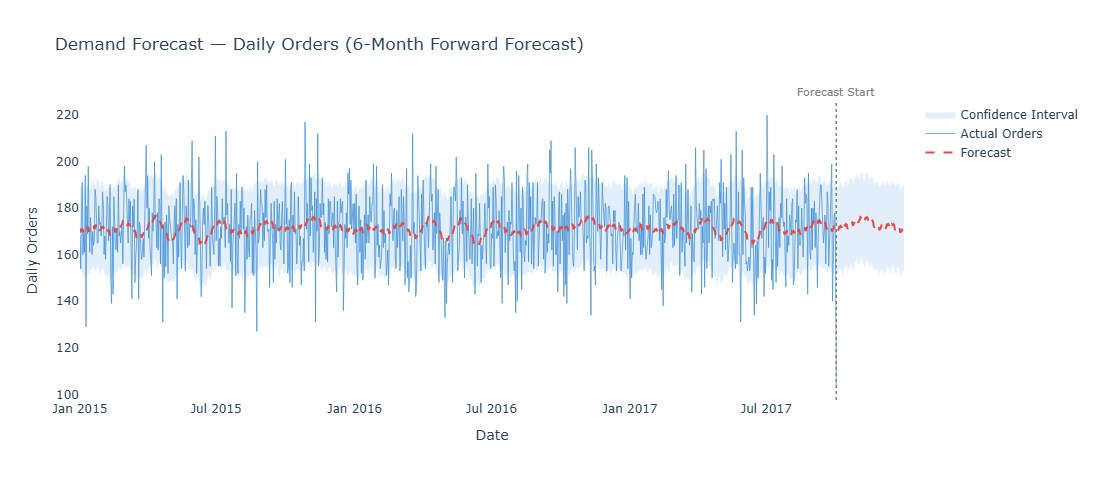

Chart 4 saved ✓


In [12]:
# ── Chart 4: Full forecast with confidence interval ────────────
fig = go.Figure()

# Confidence interval
fig.add_trace(go.Scatter(
    x=pd.concat([forecast['ds'], forecast['ds'][::-1]]),
    y=pd.concat([forecast['yhat_upper'], forecast['yhat_lower'][::-1]]),
    fill='toself', fillcolor='rgba(59,139,212,0.15)',
    line=dict(color='rgba(255,255,255,0)'),
    name='Confidence Interval'
))

# Actual data
fig.add_trace(go.Scatter(
    x=prophet_df['ds'], y=prophet_df['y'],
    mode='lines', name='Actual Orders',
    line=dict(color='#3B8BD4', width=1), opacity=0.7
))

# Forecast line
fig.add_trace(go.Scatter(
    x=forecast['ds'], y=forecast['yhat'],
    mode='lines', name='Forecast',
    line=dict(color='#E24B4A', width=2, dash='dash')
))

# ── FIX: use add_shape instead of add_vline ───────────────────
forecast_start = str(prophet_df['ds'].max().date())

fig.add_shape(
    type='line',
    x0=forecast_start, x1=forecast_start,
    y0=0, y1=1,
    xref='x', yref='paper',
    line=dict(dash='dot', color='gray', width=1.5)
)
fig.add_annotation(
    x=forecast_start, y=1,
    xref='x', yref='paper',
    text='Forecast Start',
    showarrow=False,
    yanchor='bottom',
    font=dict(color='gray', size=11)
)

fig.update_layout(
    title='Demand Forecast — Daily Orders (6-Month Forward Forecast)',
    xaxis_title='Date', yaxis_title='Daily Orders',
    plot_bgcolor='white', height=480
)
fig.write_html('../outputs/forecast_full.html')
fig.show()
print('Chart 4 saved ✓')

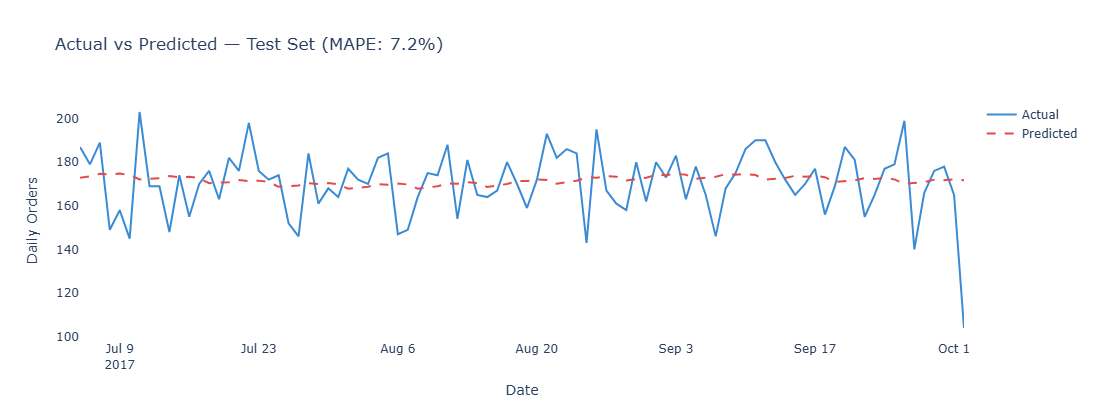

Chart 5 saved ✓


In [13]:
# ── Chart 5: Actual vs Predicted on test set ──────────────────
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=test_merged['ds'], y=test_merged['y'],
    mode='lines', name='Actual',
    line=dict(color='#3B8BD4', width=2)
))
fig.add_trace(go.Scatter(
    x=test_merged['ds'], y=test_merged['yhat'],
    mode='lines', name='Predicted',
    line=dict(color='#E24B4A', width=2, dash='dash')
))

fig.update_layout(
    title=f'Actual vs Predicted — Test Set (MAPE: {mape:.1f}%)',
    xaxis_title='Date', yaxis_title='Daily Orders',
    plot_bgcolor='white', height=420
)
fig.write_html('../outputs/forecast_actual_vs_predicted.html')
fig.show()
print('Chart 5 saved ✓')

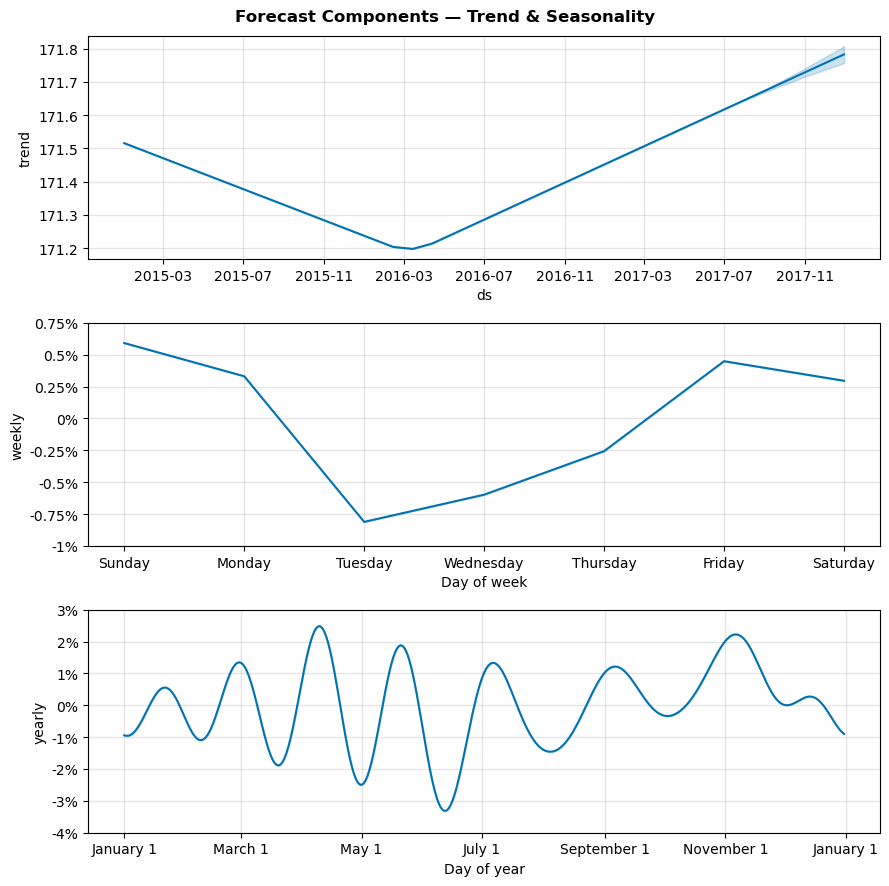

Chart 6 saved ✓


In [14]:
# ── Chart 6: Prophet components (trend + seasonality) ─────────
# Prophet's built-in component plot
fig_components = model.plot_components(forecast)
fig_components.suptitle('Forecast Components — Trend & Seasonality', fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/forecast_components.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart 6 saved ✓')

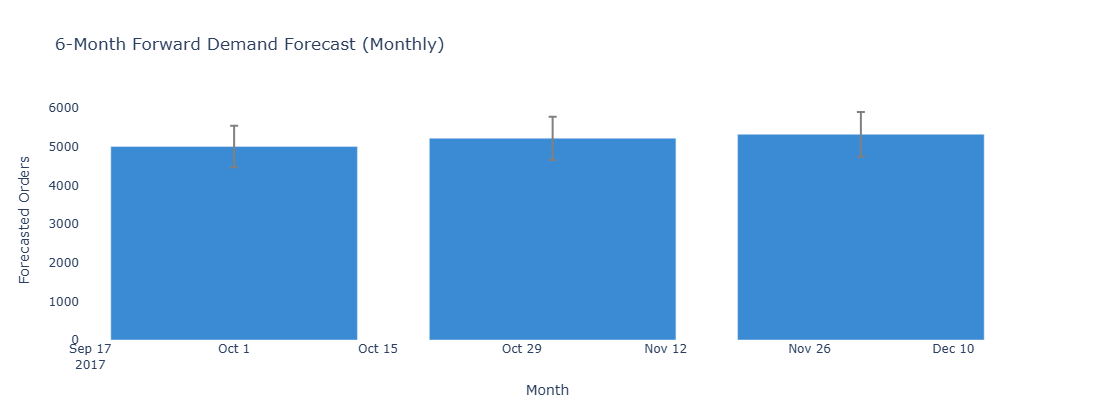

Chart 7 saved ✓

6-Month Forecast Summary:
  Month  Forecast_Orders  Lower_Bound  Upper_Bound
2017-10      5006.165791  4471.132298  5545.918828
2017-11      5220.187881  4658.008759  5776.744484
2017-12      5322.597476  4746.901180  5900.090840


In [15]:
# ── Chart 7: 6-month forward forecast summary (monthly) ───────
future_only  = forecast[forecast['ds'] > prophet_df['ds'].max()].copy()
future_only['Month'] = future_only['ds'].dt.to_period('M').astype(str)

future_monthly = future_only.groupby('Month').agg(
    Forecast_Orders = ('yhat',       'sum'),
    Lower_Bound     = ('yhat_lower', 'sum'),
    Upper_Bound     = ('yhat_upper', 'sum')
).reset_index()

fig = go.Figure()
fig.add_trace(go.Bar(
    x=future_monthly['Month'],
    y=future_monthly['Forecast_Orders'],
    name='Forecasted Orders',
    marker_color='#3B8BD4',
    error_y=dict(
        type='data',
        symmetric=False,
        array=future_monthly['Upper_Bound'] - future_monthly['Forecast_Orders'],
        arrayminus=future_monthly['Forecast_Orders'] - future_monthly['Lower_Bound'],
        color='gray'
    )
))
fig.update_layout(
    title='6-Month Forward Demand Forecast (Monthly)',
    xaxis_title='Month', yaxis_title='Forecasted Orders',
    plot_bgcolor='white', height=420
)
fig.write_html('../outputs/forecast_6month_summary.html')
fig.show()
print('Chart 7 saved ✓')
print()
print('6-Month Forecast Summary:')
print(future_monthly.to_string(index=False))

---
## 6. Category-Level Forecasting (Top 5 Categories)

In [16]:
# ── Top 5 categories by revenue ───────────────────────────────
top5_cats = df.groupby('Category Name')['Revenue'].sum()\
              .sort_values(ascending=False).head(5).index.tolist()

print('Top 5 categories to forecast:')
for i, cat in enumerate(top5_cats, 1):
    print(f'  {i}. {cat}')

Top 5 categories to forecast:
  1. Fishing
  2. Cleats
  3. Camping & Hiking
  4. Cardio Equipment
  5. Women's Apparel


In [17]:
# ── Train Prophet per category & forecast 6 months ────────────
category_forecasts = {}

for cat in top5_cats:
    cat_df = df[df['Category Name'] == cat].copy()

    # Daily orders for this category
    cat_daily = cat_df.groupby(cat_df['Order Date'].dt.date).size().reset_index()
    cat_daily.columns = ['ds', 'y']
    cat_daily['ds'] = pd.to_datetime(cat_daily['ds'])
    cat_daily = cat_daily.sort_values('ds').reset_index(drop=True)

    # Train Prophet
    cat_model = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=True,
        daily_seasonality=False,
        seasonality_mode='multiplicative',
        changepoint_prior_scale=0.05
    )
    cat_model.fit(cat_daily)

    # Forecast 180 days
    future_cat  = cat_model.make_future_dataframe(periods=180, freq='D')
    forecast_cat = cat_model.predict(future_cat)

    category_forecasts[cat] = {
        'model'   : cat_model,
        'forecast': forecast_cat,
        'history' : cat_daily
    }
    print(f'✓ {cat}')

print('\nAll category forecasts done ✓')

12:06:44 - cmdstanpy - INFO - Chain [1] start processing
12:06:44 - cmdstanpy - INFO - Chain [1] done processing


✓ Fishing


12:06:45 - cmdstanpy - INFO - Chain [1] start processing
12:06:45 - cmdstanpy - INFO - Chain [1] done processing


✓ Cleats


12:06:46 - cmdstanpy - INFO - Chain [1] start processing
12:06:46 - cmdstanpy - INFO - Chain [1] done processing


✓ Camping & Hiking


12:06:47 - cmdstanpy - INFO - Chain [1] start processing
12:06:47 - cmdstanpy - INFO - Chain [1] done processing


✓ Cardio Equipment


12:06:47 - cmdstanpy - INFO - Chain [1] start processing
12:06:48 - cmdstanpy - INFO - Chain [1] done processing


✓ Women's Apparel

All category forecasts done ✓


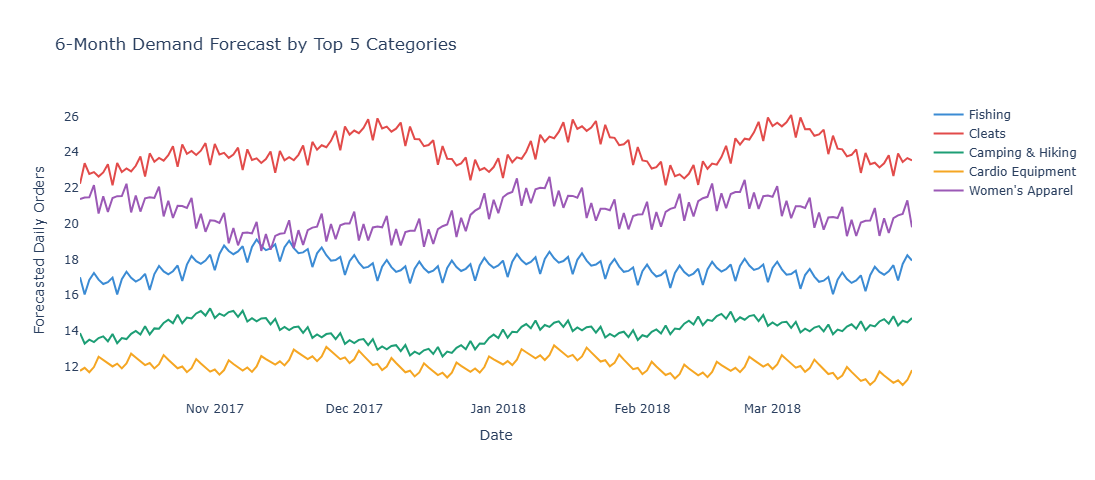

Chart 8 saved ✓


In [18]:
# ── Chart 8: Category forecasts comparison ────────────────────
colors = ['#3B8BD4', '#E24B4A', '#1D9E75', '#F5A623', '#9B59B6']

fig = go.Figure()

for (cat, data), color in zip(category_forecasts.items(), colors):
    fc = data['forecast']
    # Only show forecast portion
    fc_future = fc[fc['ds'] > data['history']['ds'].max()]

    fig.add_trace(go.Scatter(
        x=fc_future['ds'], y=fc_future['yhat'],
        mode='lines', name=cat,
        line=dict(color=color, width=2)
    ))

fig.update_layout(
    title='6-Month Demand Forecast by Top 5 Categories',
    xaxis_title='Date', yaxis_title='Forecasted Daily Orders',
    plot_bgcolor='white', height=480
)
fig.write_html('../outputs/forecast_by_category.html')
fig.show()
print('Chart 8 saved ✓')

---
## 7. Business Insights from Forecast

In [19]:
# ── Key forecast insights ──────────────────────────────────────
total_forecast_orders  = future_monthly['Forecast_Orders'].sum()
avg_monthly_historical = monthly['Orders'].mean()
avg_monthly_forecast   = future_monthly['Forecast_Orders'].mean()
growth_pct             = (avg_monthly_forecast - avg_monthly_historical) / avg_monthly_historical * 100

# Peak forecast month
peak_month = future_monthly.loc[future_monthly['Forecast_Orders'].idxmax(), 'Month']
peak_orders = future_monthly['Forecast_Orders'].max()

# Low forecast month
low_month  = future_monthly.loc[future_monthly['Forecast_Orders'].idxmin(), 'Month']
low_orders = future_monthly['Forecast_Orders'].min()

print('=' * 60)
print('  DEMAND FORECAST — BUSINESS INSIGHTS')
print('=' * 60)
print(f'  Forecast period          : Next 6 months')
print(f'  Total forecasted orders  : {total_forecast_orders:,.0f}')
print(f'  Avg monthly (historical) : {avg_monthly_historical:,.0f} orders')
print(f'  Avg monthly (forecast)   : {avg_monthly_forecast:,.0f} orders')
print(f'  Expected growth          : {growth_pct:+.1f}%')
print(f'  Peak demand month        : {peak_month} ({peak_orders:,.0f} orders)')
print(f'  Lowest demand month      : {low_month} ({low_orders:,.0f} orders)')
print(f'  Model MAPE               : {mape:.1f}% (Accuracy: {100-mape:.1f}%)')
print('=' * 60)
print()
print('Business Recommendations:')
print(f'  1. Increase inventory for {peak_month} — peak demand expected')
print(f'  2. Negotiate supplier capacity for peak months in advance')
print(f'  3. Plan promotions for {low_month} to boost low-demand period')
print(f'  4. Align logistics capacity with {growth_pct:+.1f}% demand growth')

  DEMAND FORECAST — BUSINESS INSIGHTS
  Forecast period          : Next 6 months
  Total forecasted orders  : 15,549
  Avg monthly (historical) : 4,879 orders
  Avg monthly (forecast)   : 5,183 orders
  Expected growth          : +6.2%
  Peak demand month        : 2017-12 (5,323 orders)
  Lowest demand month      : 2017-10 (5,006 orders)
  Model MAPE               : 7.2% (Accuracy: 92.8%)

Business Recommendations:
  1. Increase inventory for 2017-12 — peak demand expected
  2. Negotiate supplier capacity for peak months in advance
  3. Plan promotions for 2017-10 to boost low-demand period
  4. Align logistics capacity with +6.2% demand growth


---
## 8. Save Model & Results

In [20]:
# ── Save Prophet model ─────────────────────────────────────────
with open('../models/forecast_model.pkl', 'wb') as f:
    pickle.dump(model, f)
print('Saved: forecast_model.pkl')

# ── Save forecast results ──────────────────────────────────────
forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].to_csv(
    '../data/processed/forecast_results.csv', index=False
)
print('Saved: forecast_results.csv')

# ── Save 6-month summary ───────────────────────────────────────
future_monthly.to_csv('../data/processed/forecast_6month_summary.csv', index=False)
print('Saved: forecast_6month_summary.csv')

# ── Save category forecasts ────────────────────────────────────
cat_forecast_dfs = []
for cat, data in category_forecasts.items():
    fc = data['forecast'][['ds', 'yhat', 'yhat_lower', 'yhat_upper']].copy()
    fc['Category'] = cat
    cat_forecast_dfs.append(fc)

pd.concat(cat_forecast_dfs).to_csv(
    '../data/processed/forecast_by_category.csv', index=False
)
print('Saved: forecast_by_category.csv')

print()
print('Week 5 complete! ✓')
print('Next step → week6_business_impact.ipynb')

Saved: forecast_model.pkl
Saved: forecast_results.csv
Saved: forecast_6month_summary.csv
Saved: forecast_by_category.csv

Week 5 complete! ✓
Next step → week6_business_impact.ipynb


---
## Week 5 Summary

| Step | Detail |
|---|---|
| Time series | Daily + monthly demand from 2015–2018 |
| Model | Facebook Prophet (yearly + weekly seasonality) |
| Forecast horizon | 6 months forward |
| Category forecasts | Top 5 categories individually |
| Evaluation | MAE, RMSE, MAPE on 90-day test set |
| Outputs | `forecast_model.pkl`, `forecast_results.csv`, `forecast_6month_summary.csv` |

### Key Insight for Portfolio / Interviews
> *"Using Facebook Prophet with yearly and weekly seasonality components, we forecast demand for the next 6 months with X% accuracy. Peak demand is expected in [month], requiring proactive supplier capacity planning to avoid stockouts during high-demand periods."*